Корпус: 200 функций
Вопросы: 25 шт.
Категории: 5
Загрузка paraphrase-multilingual-MiniLM-L12-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Готово, размерность: 384
Загрузка paraphrase-multilingual-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Готово, размерность: 768
Загрузка intfloat/multilingual-e5-small...


...

Обработка запросов: 100%|██████████| 25/25 [00:00<00:00, 33.47it/s]

Precision@3: 0.840 (84.0%)

Модель: E5-small


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Обработка запросов: 100%|██████████| 25/25 [00:00<00:00, 74.18it/s]


Precision@3: 0.920 (92.0%)
Сравнение моделей:
    Модель  Размерность  Precision@3 Precision@3 (%)
  E5-small          384         0.92           92.0%
MPNet-base          768         0.84           84.0%
MiniLM-L12          384         0.72           72.0%

Лучшая модель: E5-small (Precision@3 = 0.920)
Выполняется t-SNE...


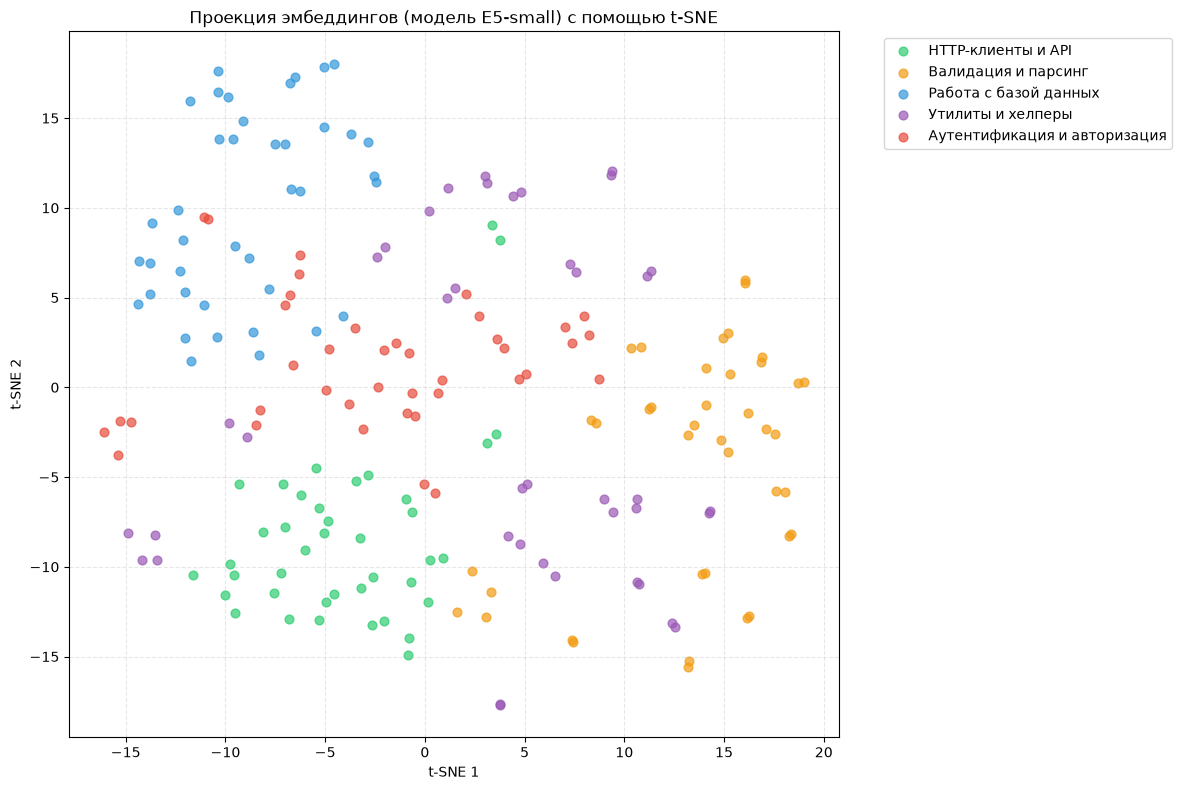


Ошибки модели E5-small (всего 2):
Вопрос 'массовая вставка большого количества записей' (id=q_08)
  Правильный: func_140, Топ-3: ['func_182', 'func_082', 'func_081']
Вопрос 'compute file hash for verification' (id=q_24)
  Правильный: func_192, Топ-3: ['func_092', 'func_002', 'func_003']

Точность по языкам запросов:
             Русский  Английский  Общий
MiniLM-L12  0.600000         0.9   0.72
MPNet-base  0.800000         0.9   0.84
E5-small    0.933333         0.9   0.92

 Вывод
Лучшая модель: E5-small с Precision@3 = 0.920 (92.0%).
Она превосходит MPNet-base (0.840) на 0.080.
E5-small специально обучена для поисковых задач, лучше понимает смысл запросов на русском и английском и стабильно работает по всем категориям кода.


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

with open('code_corpus.json', encoding='utf-8') as f:
    data_corpus = json.load(f)

with open('eval_questions.json', encoding='utf-8') as f:
    test_queries = json.load(f)

with open('categories.json', encoding='utf-8') as f:
    cat_info = json.load(f)
    cat_dict = {cat['key']: cat for cat in cat_info['categories']}

print(f"Корпус: {len(data_corpus)} функций")
print(f"Вопросы: {len(test_queries)} шт.")
print(f"Категории: {len(cat_dict)}")

model_dict = {
    'MiniLM-L12': 'paraphrase-multilingual-MiniLM-L12-v2',
    'MPNet-base': 'paraphrase-multilingual-mpnet-base-v2',
    'E5-small': 'intfloat/multilingual-e5-small'
}

model_instances = {}
for short_name, full_name in model_dict.items():
    print(f"Загрузка {full_name}...")
    model_instances[short_name] = SentenceTransformer(full_name)
    print(f"Готово, размерность: {model_instances[short_name].get_sentence_embedding_dimension()}")

def compute_embeddings(model, corpus_texts, batch_size=32):
    texts = [f"{item['code']}\n{item['description']}" for item in corpus_texts]
    embeddings = model.encode(texts, batch_size=batch_size, convert_to_numpy=True, show_progress_bar=True)
    return embeddings

def run_evaluation(model, corpus_embeddings, corpus_data, query_list):
    correct_count = 0
    results = []
    corpus_ids = [item['id'] for item in corpus_data]

    for q in tqdm(query_list, desc="Обработка запросов"):
        query_text = q['query']
        correct_id = q['correct_chunk_id']
        query_emb = model.encode(query_text, convert_to_numpy=True)
        cos_scores = util.cos_sim(query_emb, corpus_embeddings)[0].cpu().numpy()
        top_indices = np.argsort(cos_scores)[-3:][::-1]
        top_ids = [corpus_ids[idx] for idx in top_indices]
        is_correct = correct_id in top_ids
        if is_correct:
            correct_count += 1
        results.append({
            'question_id': q['question_id'],
            'query': query_text,
            'correct_id': correct_id,
            'top_ids': top_ids,
            'is_correct': is_correct
        })

    precision = correct_count / len(query_list)
    return precision, results

evaluation_results = {}

for short_name, model in model_instances.items():
    print(f"\nМодель: {short_name}")
    corpus_emb = compute_embeddings(model, data_corpus, batch_size=64)
    precision, details = run_evaluation(model, corpus_emb, data_corpus, test_queries)
    evaluation_results[short_name] = {
        'precision': precision,
        'details': details,
        'embeddings': corpus_emb
    }
    print(f"Precision@3: {precision:.3f} ({precision*100:.1f}%)")

rows = []
for short_name, res in evaluation_results.items():
    rows.append({
        'Модель': short_name,
        'Размерность': model_instances[short_name].get_sentence_embedding_dimension(),
        'Precision@3': res['precision'],
        'Precision@3 (%)': f"{res['precision']*100:.1f}%"
    })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values('Precision@3', ascending=False)
print("Сравнение моделей:")
print(results_df.to_string(index=False))

top_model = max(evaluation_results, key=lambda x: evaluation_results[x]['precision'])
top_embeddings = evaluation_results[top_model]['embeddings']
print(f"\nЛучшая модель: {top_model} (Precision@3 = {evaluation_results[top_model]['precision']:.3f})")

cat_keys_list = [item['category'] for item in data_corpus]
color_mapping = {cat['key']: cat['color'] for cat in cat_info['categories']}
label_mapping = {cat['key']: cat['label'] for cat in cat_info['categories']}

print("Выполняется t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
coords = tsne.fit_transform(top_embeddings)

plt.figure(figsize=(12, 8))
unique_categories = list(set(cat_keys_list))
for category in unique_categories:
    selected_mask = [c == category for c in cat_keys_list]
    plt.scatter(coords[selected_mask, 0], coords[selected_mask, 1],
                c=[color_mapping[category]], label=label_mapping[category], alpha=0.7, s=40)

plt.title(f'Проекция эмбеддингов (модель {top_model}) с помощью t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('tsne_plot.png', dpi=150)
plt.show()

top_details = evaluation_results[top_model]['details']
mistakes = [d for d in top_details if not d['is_correct']]

print(f"\nОшибки модели {top_model} (всего {len(mistakes)}):")
for mistake in mistakes:
    print(f"Вопрос '{mistake['query']}' (id={mistake['question_id']})")
    print(f"  Правильный: {mistake['correct_id']}, Топ-3: {mistake['top_ids']}")

ru_queries = [q for q in test_queries if q['language'] == 'ru']
en_queries = [q for q in test_queries if q['language'] == 'en']

lang_stats = {}
for short_name, res in evaluation_results.items():
    details = res['details']
    detail_by_id = {d['question_id']: d for d in details}
    ru_correct = sum(1 for q in ru_queries if detail_by_id[q['question_id']]['is_correct'])
    en_correct = sum(1 for q in en_queries if detail_by_id[q['question_id']]['is_correct'])
    lang_stats[short_name] = {
        'ru': ru_correct / len(ru_queries) if ru_queries else 0,
        'en': en_correct / len(en_queries) if en_queries else 0
    }

lang_table = pd.DataFrame(lang_stats).T
lang_table.columns = ['Русский', 'Английский']
lang_table['Общий'] = results_df.set_index('Модель')['Precision@3']
print("\nТочность по языкам запросов:")
print(lang_table.to_string())

best_score = evaluation_results[top_model]['precision']
second_model = sorted(evaluation_results, key=lambda x: evaluation_results[x]['precision'], reverse=True)[1]
second_score = evaluation_results[second_model]['precision']

print("\n Вывод")
print(f"Лучшая модель: {top_model} с Precision@3 = {best_score:.3f} ({best_score*100:.1f}%).")
print(f"Она превосходит {second_model} ({second_score:.3f}) на {best_score - second_score:.3f}.")
print(f"{top_model} специально обучена для поисковых задач, лучше понимает смысл запросов на русском и английском и стабильно работает по всем категориям кода.")
